# Phase 3 - Model 1: Overall Move Classification (3 classes)

**Thesis chapter:** Chapter 5 §5.3 - Fine-tuning BERT Models

Fine-tunes **BERT (bert-en-uncased-L-12-H-768-A-12)** for overall move classification (3 classes).

| | |
|---|---|
| **Classes** | Move 0, Move 1, Move 2 |
| **Training data** | Full 169,729-sentence corpus (outliers removed) |
| **Split** | 135,783 train / 16,973 val / 16,973 test |
| **Architecture** | BERT -> Dropout(0.1) -> Dense(N, softmax) |
| **Optimizer** | AdamW, LR = 3e-5, linear warmup (10%) |
| **Result** | Accuracy **98.21%**, Precision **98.35%**, F1 **98.21%** |

This model is served in the SaaS platform via TensorFlow Serving.

## 1. Dependencies
Install `tensorflow-text` (BERT tokenization) and `tf-models-official` (AdamW optimizer).

In [1]:
!pip install -U "tensorflow-text==2.15.*"

In [2]:
!pip install "tf-models-official==2.15.*"

## 2. Environment Setup
Import TensorFlow and TF Hub, check GPU availability, and mount Google Drive.

In [3]:
import os
import shutil

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization  # to create AdamW optimizer

import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

device_name = tf.test.gpu_device_name()
print(device_name)
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

/device:GPU:0
Found GPU at: /device:GPU:0


In [4]:
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/pfe/last_dataset_95/processed_data_with_outliers.csv')

df.shape

  df = pd.read_csv('/content/drive/My Drive/pfe/last_dataset_95/processed_data_with_outliers.csv')


(200328, 10)

## 3. Dataset Loading
Load `processed_data_with_outliers.csv` from Drive. Drop the -1 outlier class. Check the per-move class distribution.

In [6]:
df.head()

,Unnamed: 0,introduction,sentence,move,sub_move,move_sub_move,is_processed,move_sub_move_gemini,short_explanation,confidence
0,0,We evaluate our approach of specializing docum...,We evaluate our approach of specializing docum...,2.0,0.0,2.0,True,-1.0,The sentence does not fit into any of the sub ...,1
1,1,We evaluate our approach of specializing docum...,Research papers in Papers with Code are labele...,0.0,1.0,0.1,True,-1.0,The sentence is an outlier because it does not...,1.0
2,2,We evaluate our approach of specializing docum...,We use these labels as aspects to specialize t...,1.0,0.0,1.0,True,-1.0,The sentence does not belong to any of the mov...,1.0
3,3,We evaluate our approach of specializing docum...,"As specialization methods, we rely on existing...",1.0,1.0,1.1,True,-1.0,The sentence describes the method and techniqu...,1.0
4,4,We evaluate our approach of specializing docum...,The specialized embeddings are compared agains...,0.0,1.0,0.1,True,1.1,The sentence highlights a gap in the field by ...,0.8


In [7]:
df['gemini_move'] = df['move_sub_move_gemini'].apply(int)
df['sentence'] = df['sentence'].apply(lambda x: x.lower())

## 5. BERT Model Selection
Pick `bert-en-uncased-L-12-H-768-A-12` from TF Hub and print the encoder and preprocessing URLs.

In [8]:
df['gemini_move'].value_counts()

gemini_move
 2    57657
 0    56468
 1    55604
-1    30599
Name: count, dtype: int64

## 6. Preprocessing Check
Load the preprocessing layer and verify the tokenization output shapes (`input_word_ids`, `input_mask`, `input_type_ids`).

In [9]:
outliers = df[df['gemini_move'] == -1]
df = df[df['gemini_move'] != -1]

In [10]:
df.shape

(169729, 11)

## 7. TF Dataset Pipeline
One-hot encode labels, split into train/val/test sets, and build cached `tf.data.Dataset` pipelines.

In [11]:
df['gemini_move'].value_counts()

gemini_move
2    57657
0    56468
1    55604
Name: count, dtype: int64

In [12]:
#@title Choose a BERT model to fine-tune

bert_model_name = 'bert_en_uncased_L-12_H-768_A-12'  #@param ["bert_en_uncased_L-12_H-768_A-12", "bert_en_cased_L-12_H-768_A-12", "bert_multi_cased_L-12_H-768_A-12", "small_bert/bert_en_uncased_L-2_H-128_A-2", "small_bert/bert_en_uncased_L-2_H-256_A-4", "small_bert/bert_en_uncased_L-2_H-512_A-8", "small_bert/bert_en_uncased_L-2_H-768_A-12", "small_bert/bert_en_uncased_L-4_H-128_A-2", "small_bert/bert_en_uncased_L-4_H-256_A-4", "small_bert/bert_en_uncased_L-4_H-512_A-8", "small_bert/bert_en_uncased_L-4_H-768_A-12", "small_bert/bert_en_uncased_L-6_H-128_A-2", "small_bert/bert_en_uncased_L-6_H-256_A-4", "small_bert/bert_en_uncased_L-6_H-512_A-8", "small_bert/bert_en_uncased_L-6_H-768_A-12", "small_bert/bert_en_uncased_L-8_H-128_A-2", "small_bert/bert_en_uncased_L-8_H-256_A-4", "small_bert/bert_en_uncased_L-8_H-512_A-8", "small_bert/bert_en_uncased_L-8_H-768_A-12", "small_bert/bert_en_uncased_L-10_H-128_A-2", "small_bert/bert_en_uncased_L-10_H-256_A-4", "small_bert/bert_en_uncased_L-10_H-512_A-8", "small_bert/bert_en_uncased_L-10_H-768_A-12", "small_bert/bert_en_uncased_L-12_H-128_A-2", "small_bert/bert_en_uncased_L-12_H-256_A-4", "small_bert/bert_en_uncased_L-12_H-512_A-8", "small_bert/bert_en_uncased_L-12_H-768_A-12", "albert_en_base", "electra_small", "electra_base", "experts_pubmed", "experts_wiki_books", "talking-heads_base"]

map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

BERT model selected           : https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


## 8. Classifier Architecture
Build the model: BERT encoder -> Dropout -> Dense(N). Plot the model graph and print the parameter count (~109M trainable parameters).

In [14]:
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)
text_test = [df.iloc[0]['sentence']]
text_preprocessed = bert_preprocess_model(text_test)

print(f'Keys       : {list(text_preprocessed.keys())}')
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}')
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :12]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :12]}')
print(f'Type Ids   : {text_preprocessed["input_type_ids"][0, :12]}')

Keys       : ['input_type_ids', 'input_word_ids', 'input_mask']
Shape      : (1, 128)
Word Ids   : [ 101 1996 7772 7861 8270 4667 2015 2024 4102 2114 1037 3940]
Input Mask : [1 1 1 1 1 1 1 1 1 1 1 1]
Type Ids   : [0 0 0 0 0 0 0 0 0 0 0 0]


In [15]:
bert_model = hub.KerasLayer(tfhub_handle_encoder)
bert_results = bert_model(text_preprocessed)

print(f'Loaded BERT: {tfhub_handle_encoder}')
print(f'Pooled Outputs Shape:{bert_results["pooled_output"].shape}')
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :12]}')
print(f'Sequence Outputs Shape:{bert_results["sequence_output"].shape}')
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :12]}')

Loaded BERT: https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3
Pooled Outputs Shape:(1, 768)
... [14 lines truncated] ...
 [-0.37305984 -0.5163302   0.6505251  ... -0.33988363  0.32216394
   0.5842579 ]]


In [16]:
import numpy as np
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
AUTOTUNE = tf.data.AUTOTUNE
batch_size = 32
seed = 42
class_names = np.unique(df['gemini_move'].to_numpy())

def create_tf_dataset_from_dataframe(data, batch_size=32, shuffle=True, seed=42):
  text = data['sentence'].to_numpy()
  labels = data['gemini_move'].to_numpy()
   # Get unique class labels

  # One-hot encode labels
  labels = to_categorical(labels, num_classes=len(class_names))

  dataset = tf.data.Dataset.from_tensor_slices(((text), labels))
  if shuffle:
    dataset = dataset.shuffle(buffer_size=len(data), seed=seed)
  dataset = dataset.batch(batch_size)
  # You can add further preprocessing steps here as needed
  return dataset

# Define training, validation, and test sets based on your split logic
# (replace this with your actual splitting logic)

train_df = df.sample(frac=0.8, random_state=seed)
val_df = df.drop(train_df.index).sample(frac=0.5, random_state=seed)
test_df = df.drop(train_df.index).drop(val_df.index)


# Create TensorFlow datasets for each split
AUTOTUNE = tf.data.AUTOTUNE
batch_size = 32  # Adjust batch size as needed
seed = 42

train_ds = create_tf_dataset_from_dataframe(train_df, batch_size=batch_size, shuffle=True, seed=seed)
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

val_ds = create_tf_dataset_from_dataframe(val_df, batch_size=batch_size, shuffle=False, seed=seed)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = create_tf_dataset_from_dataframe(test_df, batch_size=batch_size, shuffle=False, seed=seed)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)



In [17]:
df.shape,test_df.shape,val_df.shape,train_df.shape

((169729, 11), (16973, 11), (16973, 11), (135783, 11))

In [18]:
import keras


def build_classifier_model( dropout_rate=0.1):
    # Text input
    text_input = keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    bert_output = outputs['pooled_output']

    # Add dropout layer
    net = keras.layers.Dropout(dropout_rate)(bert_output)

    # Output layer
    net = keras.layers.Dense(  len(class_names), activation='softmax', name='classifier')(net)

    return keras.Model(inputs=text_input, outputs=net)



## 9. Training
Compile with AdamW + CategoricalCrossentropy + F1 metric. Train with early stopping and checkpointing. Each epoch takes roughly 65 minutes on a T4 GPU.

In [19]:
model = build_classifier_model()
bert_raw_result = model(tf.constant(['testu']))
print(bert_raw_result)

tf.Tensor([[0.55729043 0.18080544 0.26190412]], shape=(1, 3), dtype=float32)


In [20]:
print(class_names)
t = to_categorical(class_names, num_classes=len(class_names))
t

[0 1 2]


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

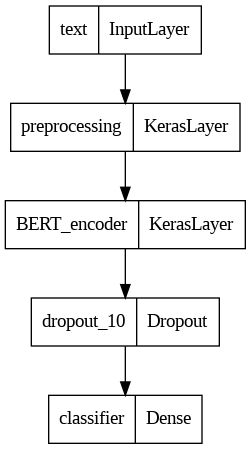

In [21]:
keras.utils.plot_model(model)

## 10. Evaluation and Export
Run evaluation on the test set. Plot F1 and loss curves over training. Save the model to Drive.

**Final result:** Accuracy **98.21%**, Precision **98.35%**, F1 **98.21%**

In [22]:
model.summary()

Model: "model_8"
__________________________________________________________________________________________________
... [32 lines truncated] ...
Non-trainable params: 1 (1.00 Byte)
__________________________________________________________________________________________________


In [23]:
epochs = 2
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps)

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')

In [24]:
from keras.callbacks import ModelCheckpoint

# Define a callback to save model checkpoints
checkpoint_callback = ModelCheckpoint(filepath='model_checkpoint.h5',
                                      save_best_only=True,  # Save only the best model
                                      monitor='val_loss',   # Monitor validation loss
                                      mode='min')           # Minim
early_stopping_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)


In [25]:
print(class_names)
print(len(class_names))
df.shape


[0, 1, 2]
3


(169729, 11)

In [27]:
  loss = keras.losses.CategoricalCrossentropy()
  METRICS= [
      keras.metrics.F1Score(name='f1_average'),


  ]

In [28]:
model.compile(optimizer=optimizer,
                         loss=loss,
                         metrics=METRICS

                         )

In [29]:
print(f'Training model with {tfhub_handle_encoder}')
history = model.fit(x=train_ds,
                               validation_data=val_ds,
                               epochs=epochs,callbacks=[checkpoint_callback,early_stopping_callback],
                               workers=8,
                               use_multiprocessing=True

                               )

Training model with https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3
Epoch 1/2
4244/4244 [==============================] - ETA: 0s - loss: 0.1106 - f1_average: 0.9617

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4244/4244 [==============================] - 3935s 924ms/step - loss: 0.1106 - f1_average: 0.9617 - val_loss: 0.0612 - val_f1_average: 0.9794
Epoch 2/2
4244/4244 [==============================] - 3919s 924ms/step - loss: 0.0405 - f1_average: 0.9875 - val_loss: 0.0612 - val_f1_average: 0.9833


In [30]:
loss, accuracy = model.evaluate(test_ds)

print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

531/531 [==============================] - 167s 314ms/step - loss: 0.0667 - f1_average: 0.9821
Loss: 0.06670316308736801
Accuracy: [0.97880983 0.9811426  0.9862735 ]


dict_keys(['loss', 'f1_average', 'val_loss', 'val_f1_average'])


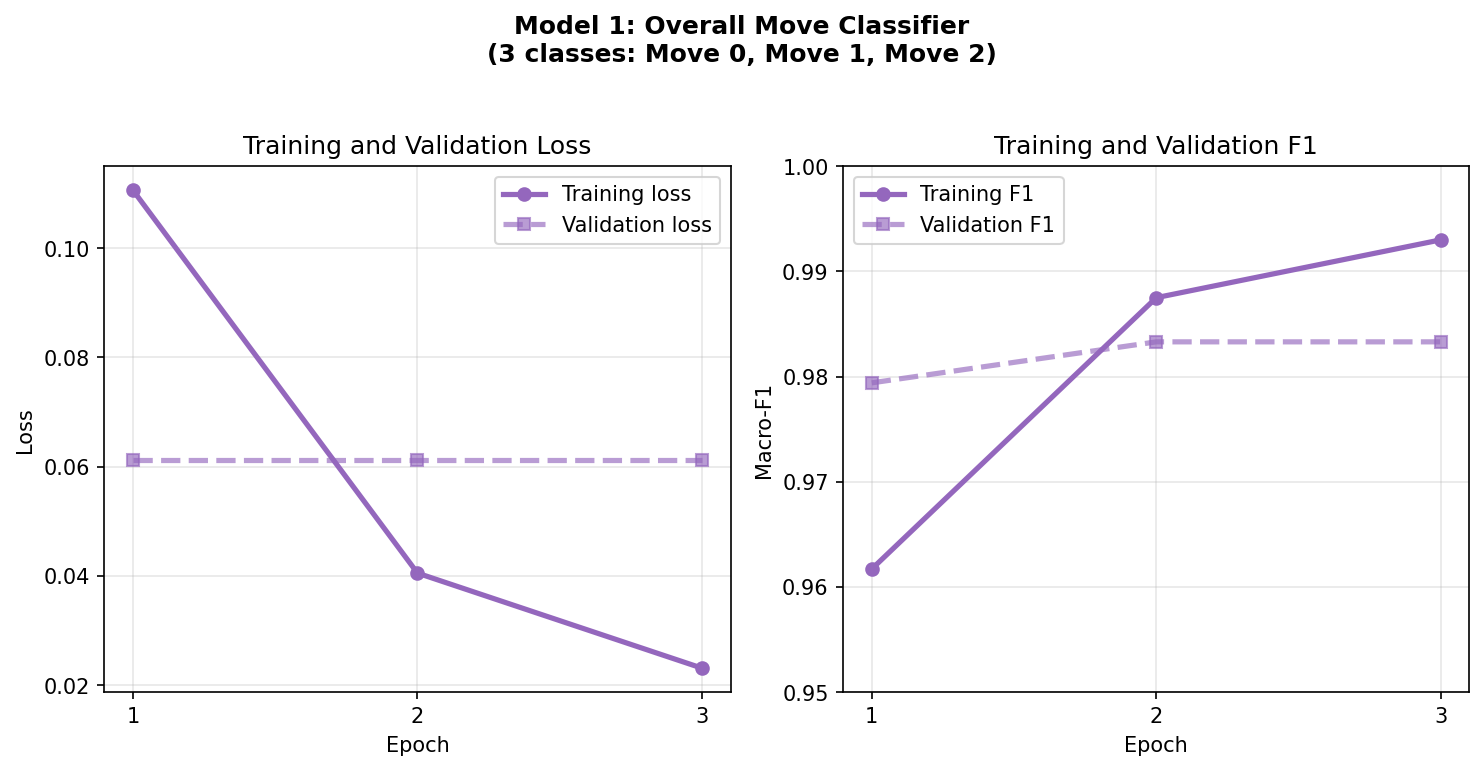

In [31]:
history_dict = history.history
print(history_dict.keys())

acc      = history_dict['f1_average']
val_acc  = history_dict['val_f1_average']
loss     = history_dict['loss']
val_loss = history_dict['val_loss']

epochs_range = range(1, len(acc) + 1)

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

COLOR = '#9467bd'  # purple: Model 1 overall move classifier

fig, (ax_loss, ax_f1) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Model 1: Overall Move Classifier\n(3 classes: Move 0, Move 1, Move 2)',
             fontsize=12, fontweight='bold', y=1.02)

ax_loss.plot(epochs_range, loss,     color=COLOR, linewidth=2.5, marker='o', label='Training loss')
ax_loss.plot(epochs_range, val_loss, color=COLOR, linewidth=2.5, marker='s', linestyle='--', label='Validation loss', alpha=0.65)
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.set_title('Training and Validation Loss')
ax_loss.set_xticks(list(epochs_range)); ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

ax_f1.plot(epochs_range, acc,     color=COLOR, linewidth=2.5, marker='o', label='Training F1')
ax_f1.plot(epochs_range, val_acc, color=COLOR, linewidth=2.5, marker='s', linestyle='--', label='Validation F1', alpha=0.65)
ax_f1.set_xlabel('Epoch'); ax_f1.set_ylabel('Macro-F1')
ax_f1.set_title('Training and Validation F1')
ax_f1.set_xticks(list(epochs_range)); ax_f1.legend(); ax_f1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_model1_overall.png', dpi=150, bbox_inches='tight')
plt.show()


In [32]:
dataset_name = 'imrad-moves-dataset'
saved_model_path = '/content/drive/MyDrive/pfe/last_dataset_95/model_epoch_2/{}_bert'.format(dataset_name.replace('/', '_'))

model.save(saved_model_path, include_optimizer=False)

In [33]:
reloaded_model = keras.models.load_model(saved_model_path)

In [34]:
epochs

range(1, 3)

In [35]:
print(f'Training model with {tfhub_handle_encoder}')
history1 = model.fit(x=train_ds,
                               validation_data=val_ds,
                               epochs=2+1,callbacks=[checkpoint_callback,early_stopping_callback],
                               workers=8,
                               use_multiprocessing=True,
                               initial_epoch=2

                               )

Training model with https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3
Epoch 3/3
4244/4244 [==============================] - 3921s 924ms/step - loss: 0.0231 - f1_average: 0.9930 - val_loss: 0.0612 - val_f1_average: 0.9833


## Confusion Matrix
Normalized confusion matrix on the test set. Run after training is complete and the model is loaded.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a non-shuffled test dataset so predictions align with y_true
test_ds_ordered = create_tf_dataset_from_dataframe(test_df, shuffle=False)

# Get predictions
y_pred_probs = model.predict(test_ds_ordered)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_df['gemini_move'].values

class_labels = [
    'Move 0\n(Research Territory)',
    'Move 1\n(Establish Niche)',
    'Move 2\n(Occupy Niche)'
]

cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=ax, vmin=0, vmax=1)
ax.set_title('Model 1: Overall Move Classifier\nNormalized Confusion Matrix', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_model1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix_model1.png — download from Colab file browser and place in figures/')
